#1 Зчитайте дані train.csv в pandas dataframe та розбийте їх на train і validation піднабори. 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

train_df = pd.read_csv(r'C:\Users\user\Desktop\python\jup\New folder\train.csv')


In [2]:
train_df, val_df = train_test_split(
    train_df, 
    test_size=0.2, 
    random_state=67, 
    stratify=train_df['Exited']
)

print(train_df.shape)
print(val_df.shape)

(12000, 14)
(3000, 14)


#2 Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній input_cols та назву колонки , яка є цільовою, в змінній target_col. Використовуючи input_cols та target_col створіть набори даних train_inputs, train_targets, val_inputs, val_targets - де inputs - вхідні дані (датафрейм), targets - дані цільової колонки відповідного піднабору.

In [3]:
target_col = 'Exited'

input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 
              'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

#3 Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [4]:
numeric_cols = train_inputs.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

print(numeric_cols)
print(categorical_cols)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
['Geography', 'Gender']


C:\Users\user\AppData\Local\Temp\ipykernel_21748\89933231.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()


#4 Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
- масштабування числових ознак,
- заповнення пропущених значень, якщо вони є,
- кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби

- передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)
- має бути виконана принаймні одна дія передобробки
- обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
- чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)
Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з train_inputs, val_inputs використовуючи display().

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [6]:
train_inputs[numeric_cols].isna().sum()

CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

In [7]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
imputer.fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])

In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_inputs[categorical_cols])

encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [9]:
final_input_cols = numeric_cols + encoded_cols

display(train_inputs[final_input_cols].head())
display(val_inputs[final_input_cols].head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
2141,-0.990793,1.856664,0.711505,-0.717118,-1.115328,0.516486,-0.978563,0.673120,1.0,0.0,0.0,0.0,1.0
9641,0.141520,0.395131,-0.730552,-0.717118,2.642622,-1.936160,1.021907,-1.206892,1.0,0.0,0.0,1.0,0.0
1736,0.058667,0.273337,-0.730552,-0.717118,2.642622,0.516486,-0.978563,0.395748,1.0,0.0,0.0,1.0,0.0
11243,-1.308393,0.029748,-0.730552,-0.717118,0.763647,0.516486,-0.978563,0.187760,0.0,0.0,1.0,0.0,1.0
10080,-0.176080,-0.701018,-0.370038,-0.717118,0.763647,0.516486,1.021907,-1.187076,1.0,0.0,0.0,1.0,0.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
5344,0.376267,0.029748,-0.370038,-0.717118,-1.115328,0.516486,1.021907,-0.157370,1.0,0.0,0.0,1.0,0.0
14505,0.735293,-1.431785,-0.370038,0.658144,0.763647,-1.936160,1.021907,-0.577774,0.0,1.0,0.0,0.0,1.0
7799,0.334841,-0.579224,0.350991,1.381133,-1.115328,0.516486,1.021907,-0.576078,1.0,0.0,0.0,0.0,1.0
4016,-0.107037,-0.701018,0.711505,-0.717118,0.763647,0.516486,-0.978563,1.388646,1.0,0.0,0.0,0.0,1.0
2061,0.652441,0.516926,-1.451581,-0.717118,-1.115328,0.516486,1.021907,-2.547732,1.0,0.0,0.0,0.0,1.0


1) Масштабування числових ознак

Без масштабування модель може давати більшу вагу колонкам, яка не відображає справжню важливість для правильності прогнозу.

2) Перевірка та заповнення пропущених значень

Пропусків не було після перевірки.

3) Кодування категоріальних ознак

Так як логістична регресія працює лише з числами, довелось колонки Geohraphy і Gender замінити на окремі бінарні колонки.


#5 Збережіть дані, що містяться в змінних train_inputs, train_targets, val_inputs, val_targets на диск в форматі parquet. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з os.listdir(your_dir) або !ls your_dir

In [10]:
import os

your_dir = 'processed_data'

os.makedirs(your_dir, exist_ok=True)

train_inputs.to_parquet(your_dir + '/train_inputs.parquet')
train_targets.to_frame().to_parquet(your_dir + '/train_targets.parquet')
val_inputs.to_parquet(your_dir + '/val_inputs.parquet')
val_targets.to_frame().to_parquet(your_dir + '/val_targets.parquet')

print(os.listdir(your_dir))

['train_inputs.parquet', 'train_targets.parquet', 'val_inputs.parquet', 'val_targets.parquet']


#6 З підготовлених вхіжних даних створіть X_train, X_val набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою LogisticRegression в scikit-learn.

In [11]:
X_train = train_inputs[final_input_cols]
X_val = val_inputs[final_input_cols]

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear')
model.fit(X_train, train_targets)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some pen

#7 Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay, roc_auc_score, f1_score

train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]



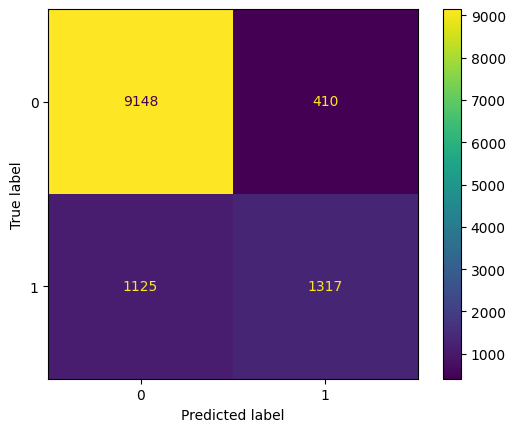

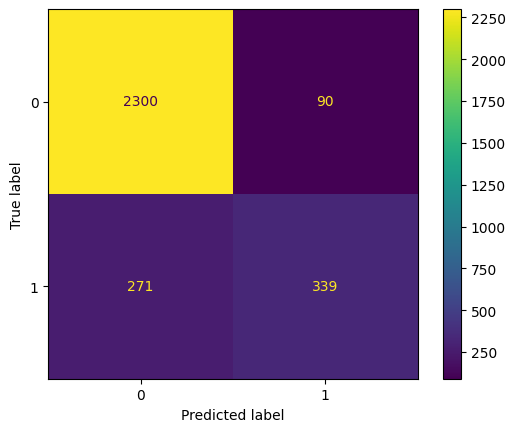

In [13]:
# Confusion Matrix
cm_train = confusion_matrix(train_targets, train_preds)
ConfusionMatrixDisplay(cm_train).plot()

cm_val = confusion_matrix(val_targets, val_preds)
ConfusionMatrixDisplay(cm_val).plot()

Train AUROC: 0.879747921179183
Val AUROC: 0.8893312298511558


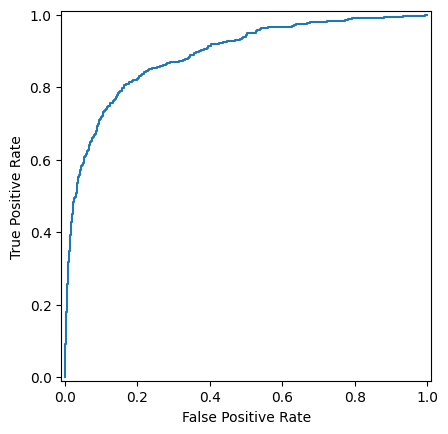

In [14]:
# ROC Curve та AUROC
fpr, tpr, thresholds = roc_curve(val_targets, val_probs)
RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

train_auroc = roc_auc_score(train_targets, train_probs)
val_auroc = roc_auc_score(val_targets, val_probs)

print('Train AUROC:', train_auroc)
print('Val AUROC:', val_auroc)

In [15]:
# F1 Score
train_f1 = f1_score(train_targets, train_preds)
val_f1 = f1_score(val_targets, val_preds)

print('Train F1:', train_f1)
print('Val F1:', val_f1)

Train F1: 0.6318061885344207
Val F1: 0.6525505293551492


Висновок: 
- Модель задовільна
- Показник АUROС: Train - 0,88, Val - 0,889. Результати вони майже однакові і вони близьки до 1, а це означає що модель додбре визначає клієнтів які залишаться, від тих хто піде.
- F1 Score: Train - 0.632, Val - 0.653. Середній результат. 
- Модель визначила 2300 клієнтів, які залишились і 339, які пішли. Модель помилилась в 271 випадку, неправильно давши оцінку (визначило як "залишиться", але клієнт пішов) і в 90 випадках визначило, що клієнт пішов, хоча він залишився.

#8 Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [16]:
majority_class = train_targets.mode()[0]
print(majority_class)

train_baseline_preds = [majority_class] * len(train_targets)
val_baseline_preds = [majority_class] * len(val_targets)

from sklearn.metrics import accuracy_score

train_baseline_acc = accuracy_score(train_targets, train_baseline_preds)
val_baseline_acc = accuracy_score(val_targets, val_baseline_preds)

print('Baseline Train Accuracy:', train_baseline_acc)
print('Baseline Val Accuracy:', val_baseline_acc)

0.0
Baseline Train Accuracy: 0.7965
Baseline Val Accuracy: 0.7966666666666666


Висновок:
- Логістична модель краща за Baseline model, тому що вона навчилась розпізнавати клієнтів, які хочуть піти, а Baseline model цього робити не вміє
- вибірка клієнтів мала, і частка клієнтів яка йде 20%, тому baseline model буде часто вгадувати, хто з клієнтів піде.

#9 бережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл log_reg.joblib. Потім завантажте модель з файлу в змінну model_2 (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [17]:
import joblib

joblib.dump(model, 'log_reg.joblib')

model_2 = joblib.load('log_reg.joblib')

print(model_2)

LogisticRegression(solver='liblinear')


Ознайомтесь з роботою наведеної функції predict_raw_df. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.
Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [18]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df):
    input_df = input_df.copy()
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:, 1]
    return prob

#11 Зчитайте дані з test.csv в змінну test_raw_df. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку Exited в датафреймі test_raw_df.

In [19]:
test_raw_df = pd.read_csv(r'C:\Users\user\Desktop\python\jup\New folder\test.csv')

test_raw_df['Exited'] = predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, test_raw_df)

test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.075052
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.032628
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.148532
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.191287
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.052009


#12 Зчитайте файл 'sample_submission.csv' і зповніть колонку Exited передбаченими вашою моделлю значеннями для кожного відповідного id клієнта. Виведіть перші 5 рядків фінального датасету, збережіть результат в файл submission_log_reg.csv 

In [25]:
data_dir = r'C:\Users\user\Desktop\python\jup\New folder'

test_raw_df = pd.read_csv(data_dir + '\\test.csv')
test_raw_df['Exited'] = predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, test_raw_df)

submission_df = pd.read_csv(data_dir + '\\sample_submission.csv')
submission_df['Exited'] = test_raw_df['Exited'].values

submission_df.head()




,id,Exited
0,15000,0.075052
1,15001,0.032628
2,15002,0.148532
3,15003,0.191287
4,15004,0.052009


In [26]:
submission_df.to_csv(data_dir + '\\submission_log_reg.csv', index=False)
